In [5]:
import sys
sys.path.append('../simulation')
from filter_functions import F_Ramsey, F_Hahn, F_CPMG, F_XY8

c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\filter_functions.py:4: RuntimeWarning: invalid value encountered in divide
  return np.where(omega == 0, t ** 2, (4 * (np.sin(omega * t / 2) ** 2)) / (omega ** 2))
c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\filter_functions.py:7: RuntimeWarning: invalid value encountered in divide
  return np.where(omega == 0, 0 , (16 * (np.sin(omega * t / 4) ** 4) / omega ** 2))


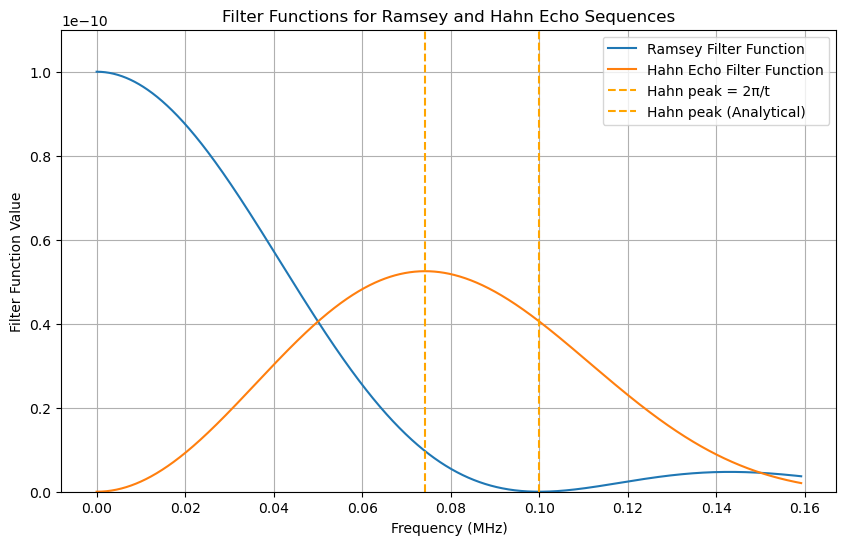

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = 10e-6
omega = np.linspace(0, 1e6, 1000)
omega_MHz = omega / (2 * np.pi * 1e6)
F_Ramsey_values = F_Ramsey(omega, t)
F_Hahn_values = F_Hahn(omega, t)

plt.figure(figsize=(10, 6))
plt.plot(omega_MHz, F_Ramsey_values, label='Ramsey Filter Function')
plt.plot(omega_MHz, F_Hahn_values, label='Hahn Echo Filter Function')
plt.axvline(x=2*np.pi/t / (2*np.pi*1e6), color='orange', linestyle='--', label='Hahn peak = 2π/t')
plt.axvline(x=omega_MHz[np.argmax(F_Hahn_values)], color='orange', linestyle='--', label='Hahn peak (Analytical)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('Filter Functions for Ramsey and Hahn Echo Sequences')
plt.legend()
plt.grid()
plt.ylim(0, max(max(F_Ramsey_values), max(F_Hahn_values)) * 1.1)
plt.show()




In [3]:
np.allclose(F_CPMG(omega, t, 1), F_Hahn(omega, t))

True

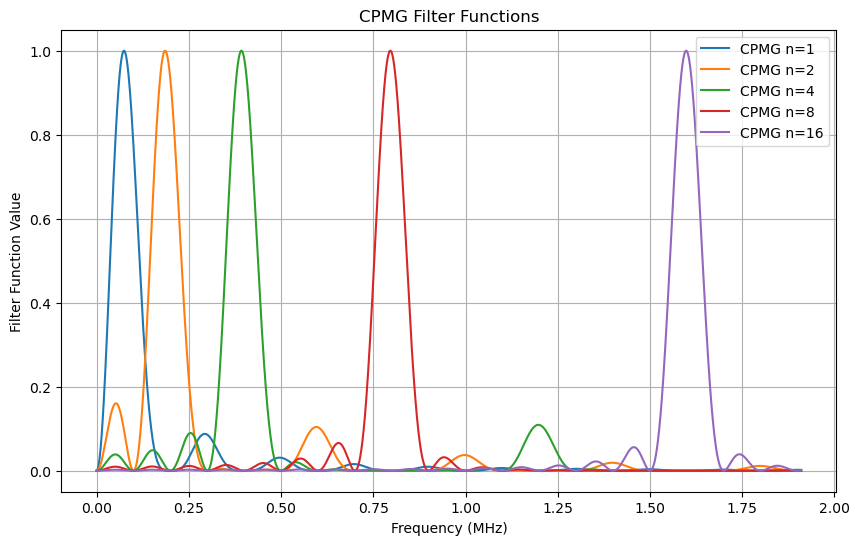

In [4]:
omega = np.linspace(0, 12e6, 10000)
omega_MHz = omega / (2 * np.pi * 1e6)

plt.figure(figsize=(10, 6))
for n in [1, 2, 4, 8, 16]:
    F_CPMG_values = F_CPMG(omega, t, n)
    plt.plot(omega_MHz, F_CPMG_values / np.max(F_CPMG_values), label=f'CPMG n={n}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('CPMG Filter Functions')
plt.legend()
plt.grid()
plt.show()

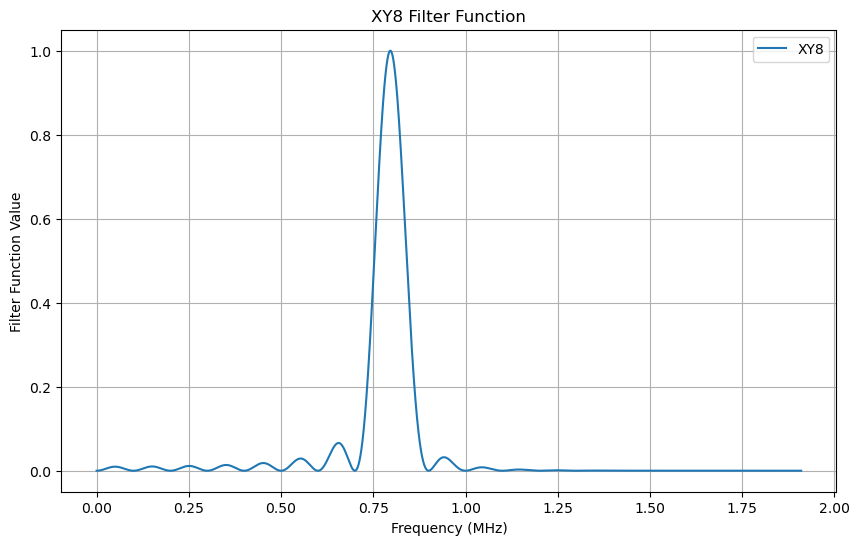

In [6]:
F_XY8_values = F_XY8(omega, t)
plt.figure(figsize=(10, 6))
plt.plot(omega_MHz, F_XY8_values / np.max(F_XY8_values), label='XY8')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Function Value')
plt.title('XY8 Filter Function')
plt.legend()
plt.grid()
plt.show()
